# SHAP Explainability Analysis

Interpreting which feature differences drive pairwise flat preferences,  
using SHAP (SHapley Additive exPlanations) on our two best models:
- **HistGBM** (best tree model, AUC 0.901) — via TreeExplainer
- **MLP 1-layer / RankNet** (best overall, AUC 0.910) — via KernelExplainer

## Setup

In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

shap.initjs()

/Users/caspe2/NUS/Y3S2/CS3264/cs3264-hdb/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data & Models

In [3]:
df = pd.read_csv("df_pairwise.csv")

weight_cols = [
    "weight_transport", "weight_essentials", "weight_lifestyle",
    "weight_recreation", "weight_health", "weight_storey",
    "weight_lease", "weight_office", "weight_parents",
]
diff_cols = [c for c in df.columns if c.startswith("diff_")]
feature_cols = weight_cols + diff_cols

# Same split as model_pairwise.ipynb
user_ids = df["user_id"].unique()
train_users, val_users = train_test_split(user_ids, test_size=0.2, random_state=42)
val_df = df[df["user_id"].isin(val_users)].copy()
X_val = val_df[feature_cols]

# Load saved models
hgb_clf = joblib.load("models/hgb_clf.joblib")
mlp_best = joblib.load("models/mlp_1layer.joblib")
scaler = joblib.load("models/scaler.joblib")

X_val_scaled = scaler.transform(X_val.values)

print(f"Validation set: {X_val.shape}")
print(f"Models loaded successfully.")

Validation set: (12000, 27)
Models loaded successfully.


---
## 1. HistGBM — SHAP TreeExplainer

TreeExplainer computes exact SHAP values efficiently for tree-based models.

In [4]:
explainer_hgb = shap.TreeExplainer(hgb_clf)
shap_values_hgb = explainer_hgb.shap_values(X_val)

print(f"SHAP values shape: {shap_values_hgb.shape}")

SHAP values shape: (12000, 27)


### Summary Plot — Global Feature Importance

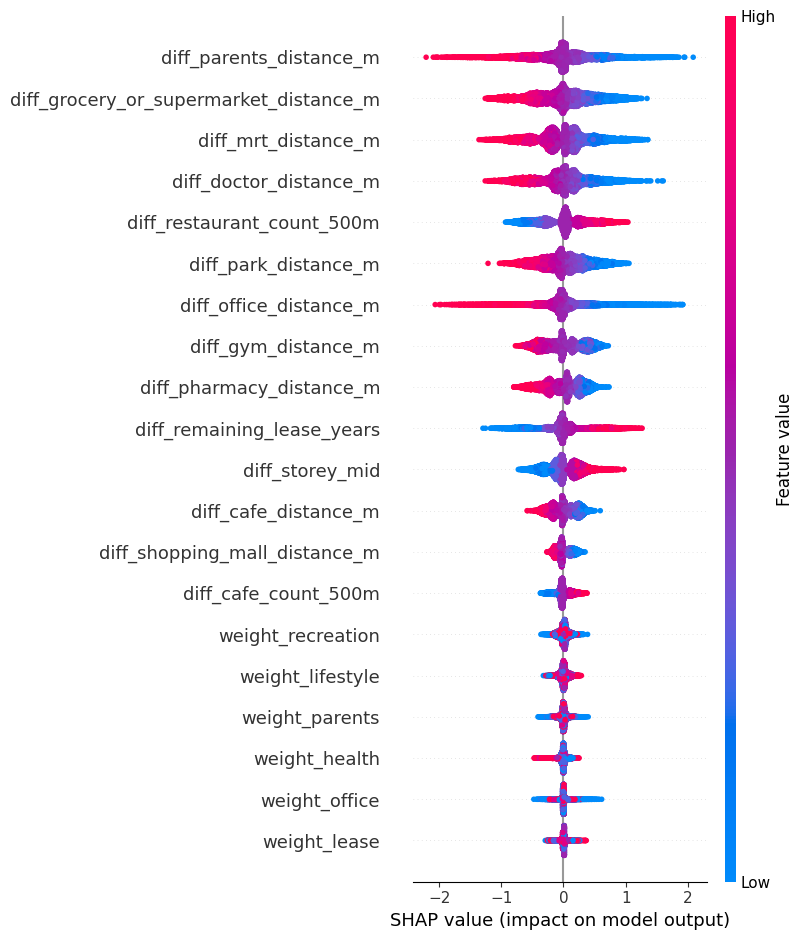

In [5]:
shap.summary_plot(shap_values_hgb, X_val, feature_names=feature_cols, show=True)

### Bar Plot — Mean Absolute SHAP Values

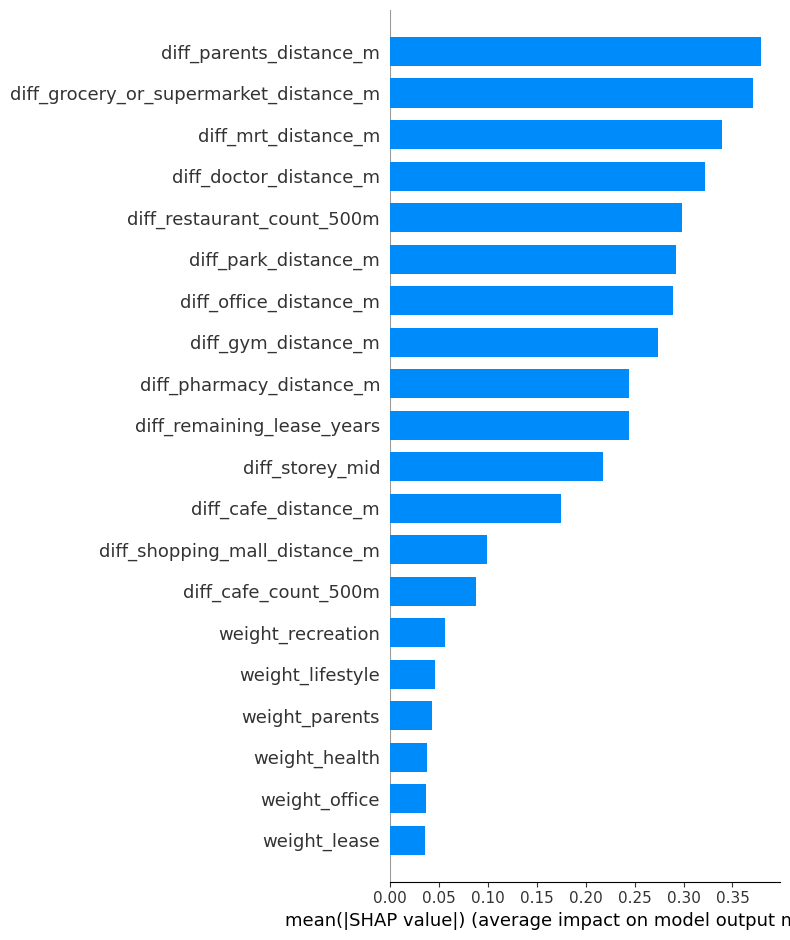

In [6]:
shap.summary_plot(shap_values_hgb, X_val, feature_names=feature_cols, plot_type="bar", show=True)

---
## 2. MLP (RankNet) — SHAP KernelExplainer

KernelExplainer is model-agnostic but slower, so we subsample the background dataset.

In [8]:
# Subsample background data for KernelExplainer (100 samples for speed)
np.random.seed(42)
bg_idx = np.random.choice(len(X_val_scaled), size=300, replace=False)
background = X_val_scaled[bg_idx]

# Subsample explanation set (200 samples)
explain_idx = np.random.choice(len(X_val_scaled), size=600, replace=False)
X_explain = X_val_scaled[explain_idx]

explainer_mlp = shap.KernelExplainer(mlp_best.predict_proba, background)
shap_values_mlp = explainer_mlp.shap_values(X_explain)

# SHAP v0.51+ returns (n_samples, n_features, n_classes) instead of a list
if isinstance(shap_values_mlp, list):
    shap_values_mlp_1 = shap_values_mlp[1]
else:
    shap_values_mlp_1 = shap_values_mlp[:, :, 1]
print(f"MLP SHAP values shape: {shap_values_mlp_1.shape}")

Using 300 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 600/600 [01:51<00:00,  5.39it/s]

MLP SHAP values shape: (600, 27)


### Summary Plot — MLP (RankNet)

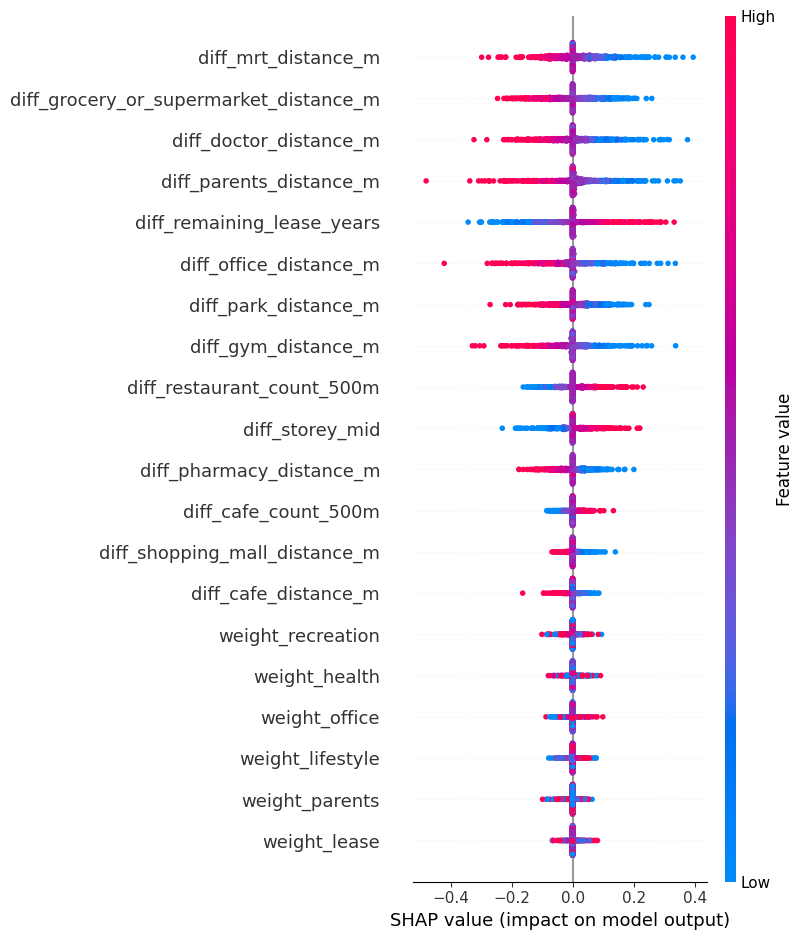

In [9]:
shap.summary_plot(shap_values_mlp_1, X_explain, feature_names=feature_cols, show=True)

---
## 3. Comparison: HistGBM vs MLP Feature Importance

Do both models agree on which features matter most?

Grouped Feature Importance Comparison


,group,HistGBM |SHAP|,MLP |SHAP|,HistGBM Rank,MLP Rank
0,Lifestyle,0.713329,0.078326,1,3
1,Recreation,0.622777,0.099224,2,2
2,Health,0.604777,0.100026,3,1
3,Parents Proximity,0.422315,0.061634,4,6
4,Essentials,0.387946,0.065477,5,5
5,Transport,0.385180,0.067633,6,4
6,Office Proximity,0.325984,0.055966,7,8
7,Lease,0.280359,0.059936,8,7
8,Storey,0.252703,0.040320,9,9


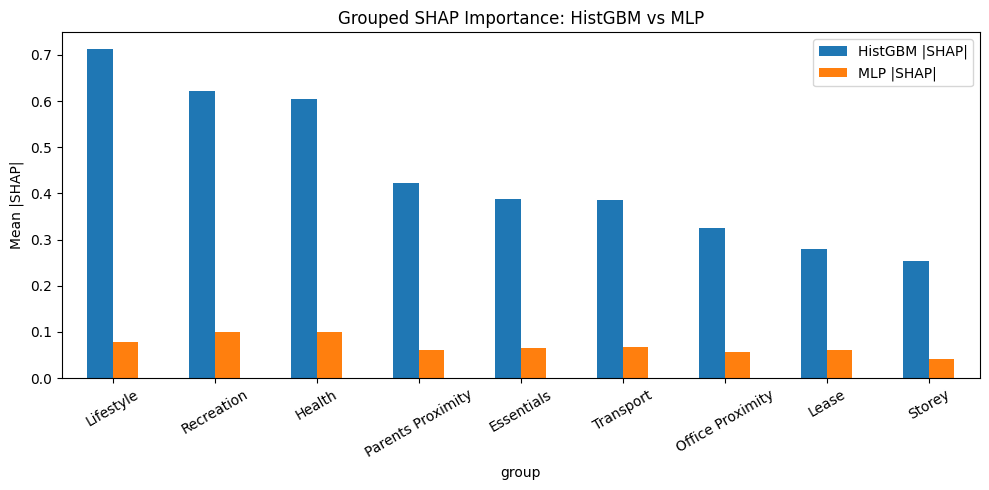

In [12]:
FEATURE_GROUPS = {
    "Lifestyle":          ["diff_restaurant_distance_m", "diff_restaurant_count_500m",
                           "diff_cafe_distance_m", "diff_cafe_count_500m",
                           "diff_shopping_mall_distance_m", "weight_lifestyle"],
    "Recreation":         ["diff_park_distance_m", "diff_gym_distance_m", "weight_recreation"],
    "Parents Proximity":  ["diff_parents_distance_m", "weight_parents"],
    "Health":             ["diff_doctor_distance_m", "diff_pharmacy_distance_m", "weight_health"],
    "Office Proximity":   ["diff_office_distance_m", "weight_office"],
    "Essentials":         ["diff_grocery_or_supermarket_distance_m", "weight_essentials"],
    "Transport":          ["diff_mrt_distance_m", "diff_bus_distance_m",
                           "diff_bus_count_500m", "weight_transport"],
    "Storey":             ["diff_storey_mid", "weight_storey"],
    "Lease":              ["diff_remaining_lease_years", "weight_lease"],
}

# Build per-feature SHAP df
feature_shap_df = pd.DataFrame({
    "feature":       feature_cols,
    "hgb_shap":      np.abs(shap_values_hgb).mean(axis=0),
    "mlp_shap":      np.abs(shap_values_mlp_1).mean(axis=0),
})

# Assign group label
def get_group(feature):
    for group, features in FEATURE_GROUPS.items():
        if feature in features:
            return group
    return "Other"

feature_shap_df["group"] = feature_shap_df["feature"].apply(get_group)

# Aggregate by group (sum of mean |SHAP| within group)
group_df = (
    feature_shap_df.groupby("group")[["hgb_shap", "mlp_shap"]]
    .sum()
    .rename(columns={"hgb_shap": "HistGBM |SHAP|", "mlp_shap": "MLP |SHAP|"})
    .reset_index()
)

group_df = group_df[group_df["group"] != "Other"]

group_df["HistGBM Rank"] = group_df["HistGBM |SHAP|"].rank(ascending=False).astype(int)
group_df["MLP Rank"]     = group_df["MLP |SHAP|"].rank(ascending=False).astype(int)
group_df = group_df.sort_values("HistGBM |SHAP|", ascending=False).reset_index(drop=True)

print("Grouped Feature Importance Comparison")
print("=" * 60)
display(group_df)

# Bar chart comparison
group_df.set_index("group")[["HistGBM |SHAP|", "MLP |SHAP|"]].plot(
    kind="bar", figsize=(10, 5), rot=30
)
plt.title("Grouped SHAP Importance: HistGBM vs MLP")
plt.ylabel("Mean |SHAP|")
plt.tight_layout()
plt.savefig("shap_group_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

## 4. Explaining features of recommendation for MLP model

In [13]:
from math import radians, sin, cos, sqrt, atan2

# Load flat and user data
df_flats_clean = pd.read_csv("df_flats_clean.csv")
df_users = pd.read_csv("df_users.csv")

# copied from process_data.ipynb
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def safe_distance_score(dist_m, cap=2000):
    if pd.isna(dist_m): return 0.0
    return max(0.0, 1 - (min(dist_m, cap) / cap))

def safe_count_score(count, cap=5):
    if pd.isna(count): return 0.0
    return min(count, cap) / cap

def get_user_candidates(user_row, df_flats):
    candidates = df_flats.copy()
    candidates = candidates[candidates["resale_price"] <= user_row["budget_max"]]
    candidates = candidates[candidates["flat_type"].str.upper() == str(user_row["preferred_flat_type"]).upper()]
    return candidates

def compute_user_distances(candidates, user_row):
    """Only compute the user-specific distances not in df_flats_clean."""
    c = candidates.copy()
    c["office_distance_m"] = c.apply(
        lambda r: haversine_distance(r["latitude"], r["longitude"],
                                     user_row["office_lat"], user_row["office_lon"]), axis=1)
    c["parents_distance_m"] = c.apply(
        lambda r: haversine_distance(r["latitude"], r["longitude"],
                                     user_row["parent_lat"], user_row["parent_lon"]), axis=1)
    return c

In [14]:
FEATURE_LABELS = {
    # weight features
    "weight_transport":                        "Importance: Transport",
    "weight_essentials":                       "Importance: Supermarket",
    "weight_lifestyle":                        "Importance: Lifestyle (Cafes/Restaurants/Malls)",
    "weight_recreation":                       "Importance: Recreation (Parks/Gyms)",
    "weight_health":                           "Importance: Healthcare",
    "weight_storey":                           "Importance: Floor Level",
    "weight_lease":                            "Importance: Remaining Lease",
    "weight_office":                           "Importance: Proximity to Office",
    "weight_parents":                          "Importance: Proximity to Parents",
    # diff features
    "diff_mrt_distance_m":                     "MRT Distance (vs typical)",
    "diff_bus_distance_m":                     "Bus Stop Distance (vs typical)",
    "diff_bus_count_500m":                     "Bus Stops within 500m (vs typical)",
    "diff_grocery_or_supermarket_distance_m":  "Supermarket Distance (vs typical)",
    "diff_shopping_mall_distance_m":           "Mall Distance (vs typical)",
    "diff_restaurant_distance_m":             "Nearest Restaurant Distance (vs typical)",
    "diff_restaurant_count_500m":              "Restaurants within 500m (vs typical)",
    "diff_cafe_distance_m":                    "Nearest Cafe Distance (vs typical)",
    "diff_cafe_count_500m":                    "Cafes within 500m (vs typical)",
    "diff_park_distance_m":                    "Park Distance (vs typical)",
    "diff_gym_distance_m":                     "Gym Distance (vs typical)",
    "diff_doctor_distance_m":                  "Clinic Distance (vs typical)",
    "diff_pharmacy_distance_m":                "Pharmacy Distance (vs typical)",
    "diff_storey_mid":                         "Floor Level (vs typical)",
    "diff_remaining_lease_years":              "Remaining Lease Years (vs typical)",
    "diff_floor_area_sqm":                     "Floor Area sqm (vs typical)",
    "diff_office_distance_m":                  "Distance to Your Office (vs typical)",
    "diff_parents_distance_m":                 "Distance to Parents' Home (vs typical)",
}

In [26]:
def recommend_full(mlp_best, scaler, user_row, df_flats, weight_cols, raw_cols, feature_cols, top_k=5, explain_rank=1):
    """Score ALL eligible flats for a user and return top K with SHAP explanation."""

    # Step 1: hard filter by budget + flat_type
    candidates = get_user_candidates(user_row, df_flats).reset_index(drop=True)
    if len(candidates) == 0:
        print("No eligible flats found.")
        return
    print(f"Eligible flats: {len(candidates)}")

    # Step 2: compute user-specific distances (office + parents)
    candidates = compute_user_distances(candidates, user_row)

    # Step 3: build diff features vs median reference flat
    ref = candidates[raw_cols].median()
    diff_features = candidates[raw_cols].subtract(ref)
    diff_features.columns = [f"diff_{c}" for c in raw_cols]
    for col in weight_cols:
        diff_features[col] = user_row[col]

    input_df = diff_features[feature_cols]
    input_scaled = scaler.transform(input_df.values)

    # Step 4: rank all flats by win probability
    candidates["win_prob"] = mlp_best.predict_proba(input_scaled)[:, 1]
    candidates = candidates.sort_values("win_prob", ascending=False).drop_duplicates(subset="flat_id")
    top_k_df = candidates.nlargest(top_k, "win_prob").reset_index()

    # Step 5: print user profile
    print(f"\nUser {user_row['user_id']} — Preference Profile:")
    print("-" * 40)
    for col in weight_cols:
        label = col
        val = int(user_row[col])
        bar = "█" * val + "░" * (5 - val)
        print(f"  {label:<30} {bar}  ({val}/5)")

    # Step 6: print top K recommendations
    print(f"\nTop {top_k} Recommendations:")
    print("-" * 40)
    display(top_k_df[[
        "flat_id", "flat_type", "resale_price", "floor_area_sqm",
        "storey_mid", "remaining_lease_years", "mrt_distance_m", "win_prob"
    ]])

    # Step 7: SHAP explanation for rank #1
    print(f"\nExplaining Rank #1: {top_k_df.iloc[0]['flat_id']}")
    top_idx = top_k_df.iloc[explain_rank-1]["index"]
    
    np.random.seed(42)
    bg_idx = np.random.choice(len(input_scaled), size=min(50, len(input_scaled)), replace=False)
    background = input_scaled[bg_idx]
    explainer = shap.KernelExplainer(mlp_best.predict_proba, background)
    shap_vals = explainer.shap_values(input_scaled[[top_idx]], nsamples=500)
    sv = shap_vals[1][0] if isinstance(shap_vals, list) else shap_vals[0, :, 1]

    shap_explanation = shap.Explanation(
        values=sv,
        base_values=explainer.expected_value[1],
        data=input_df.iloc[top_idx].values,
        feature_names=[FEATURE_LABELS.get(f, f) for f in feature_cols]
    )
    plt.figure(figsize=(14, 8))
    shap.waterfall_plot(shap_explanation, max_display=10, show=False)
    plt.savefig(f"shap_waterfall_U10.png", bbox_inches="tight", dpi=150)

    return top_k_df

In [28]:
weight_cols = [
    "weight_transport", "weight_essentials", "weight_lifestyle",
    "weight_recreation", "weight_health", "weight_storey",
    "weight_lease", "weight_office", "weight_parents",
]

raw_cols = [
    "mrt_distance_m", "bus_distance_m", "bus_count_500m",
    "grocery_or_supermarket_distance_m", "shopping_mall_distance_m",
    "restaurant_distance_m", "restaurant_count_500m",
    "cafe_distance_m", "cafe_count_500m",
    "park_distance_m", "gym_distance_m",
    "doctor_distance_m", "pharmacy_distance_m",
    "storey_mid", "remaining_lease_years", "floor_area_sqm",
    "office_distance_m", "parents_distance_m",
]

feature_cols = weight_cols + [f"diff_{c}" for c in raw_cols]

# --- Demo user ---
user_row = df_users[df_users["user_id"] == "U10"].iloc[0]
print(user_row)
recommend_full(mlp_best, scaler, user_row, df_flats_clean,
               weight_cols, raw_cols, feature_cols, top_k=5, explain_rank=1)

user_id                       U10
budget_max                 350000
preferred_flat_type        2 ROOM
weight_transport                3
weight_essentials               2
weight_lifestyle                2
weight_recreation               2
weight_health                   2
weight_storey                   1
weight_lease                    5
weight_office                   1
weight_parents                  4
parent_lat               1.337773
parent_lon             103.775131
office_lat                  1.437
office_lon               103.7863
Name: 9, dtype: object
Eligible flats: 3507

User U10 — Preference Profile:
----------------------------------------
  weight_transport               ███░░  (3/5)
  weight_essentials              ██░░░  (2/5)
  weight_lifestyle               ██░░░  (2/5)
  weight_recreation              ██░░░  (2/5)
  weight_health                  ██░░░  (2/5)
  weight_storey                  █░░░░  (1/5)
  weight_lease                   █████  (5/5)
  weight_office  

,flat_id,flat_type,resale_price,floor_area_sqm,storey_mid,remaining_lease_years,mrt_distance_m,win_prob
0,698A_JURONG WEST CTRL 3_2 ROOM_,2 ROOM,330000.0,47.0,2.0,93.583333,352.046263,0.971623
1,32_NEW MKT RD_2 ROOM_,2 ROOM,295000.0,52.0,8.0,64.583333,109.391318,0.965041
2,26_GHIM MOH LINK_2 ROOM_,2 ROOM,346500.0,47.0,11.0,92.916667,532.948171,0.961933
3,27_GHIM MOH LINK_2 ROOM_,2 ROOM,320000.0,47.0,8.0,92.833333,577.580455,0.951662
4,51_C'WEALTH DR_2 ROOM_,2 ROOM,327000.0,47.0,11.0,94.916667,124.708167,0.920315



Explaining Rank #1: 698A_JURONG WEST CTRL 3_2 ROOM_


100%|██████████| 1/1 [00:00<00:00, 38.80it/s]


,index,flat_id,flat_type,flat_model,floor_area_sqm,resale_price,latitude,longitude,remaining_lease_years,storey_mid,...,cafe_distance_m,restaurant_distance_m,gym_distance_m,cafe_count_500m,restaurant_count_500m,doctor_distance_m,pharmacy_distance_m,office_distance_m,parents_distance_m,win_prob
0,2306,698A_JURONG WEST CTRL 3_2 ROOM_,2 ROOM,Model A,47.0,330000.0,1.341092,103.708024,93.583333,2.0,...,208.536445,223.298658,686.223654,8,8,410.052390,235.864661,13763.939276,7469.045979,0.971623
1,136,32_NEW MKT RD_2 ROOM_,2 ROOM,Standard,52.0,295000.0,1.284859,103.842579,64.583333,8.0,...,152.587217,41.408860,185.388451,10,9,183.548408,140.580336,18037.076650,9530.899528,0.965041
2,601,26_GHIM MOH LINK_2 ROOM_,2 ROOM,Model A,47.0,346500.0,1.308388,103.785551,92.916667,11.0,...,370.312909,410.639384,1132.545463,3,2,859.856966,386.993338,14301.215144,3466.705140,0.961933
3,639,27_GHIM MOH LINK_2 ROOM_,2 ROOM,Model A,47.0,320000.0,1.308371,103.785134,92.833333,8.0,...,410.964134,435.525895,1168.101368,3,2,905.512668,428.124503,14303.450713,3453.253854,0.951662
4,578,51_C'WEALTH DR_2 ROOM_,2 ROOM,Model A,47.0,327000.0,1.301535,103.797640,94.916667,11.0,...,638.536737,111.380967,461.255762,0,1,801.533980,1028.892230,15115.694458,4743.241983,0.920315
